

#***Autocorrelation:***

##**Technical Definition**:
**ACF: Autocorrelation function**

\begin{equation}
ACF_k = \frac{\text{Cov}(X_t, X_{t-k})}{\sqrt{\text{Var}(X_t) \cdot \text{Var}(X_{t-k})}}
\end{equation}

**PACF: Partial ACF**

\begin{equation}
PACF_k = \text{Corr}\left( X_t, X_{t-k} \mid X_{t-1}, X_{t-2}, \dots, X_{t-k+1} \right)
\end{equation}

or

\begin{equation}
PACF_k = \frac{\text{Cov}(X_t, X_{t-k} \mid X_{t-1}, X_{t-2}, \dots, X_{t-k+1})}{\sqrt{\text{Var}(X_t \mid X_{t-1}, X_{t-2}, \dots, X_{t-k+1}) \cdot \text{Var}(X_{t-k} \mid X_{t-1}, X_{t-2}, \dots, X_{t-k+1})}}
\end{equation}


**Ljung-Box test**

\begin{equation}
Q = n (n + 2) \sum_{k=1}^{m} \frac{ACF_k^2}{n - k}
\end{equation}
for m lags, we check the null hypothesis (goes as a chi test) that the m lags have no autocorrelation and thus no memory


# **Decription**:


 Autocorrelation measures the linear correlation of a time series with a lagged version of itself. It captures the degree of linear dependence between observations at different time points in the same series, while when we say partial we mean the same thing after taking into account what is between the Lags.

#**Demonstration**:



[*********************100%***********************]  1 of 1 completed


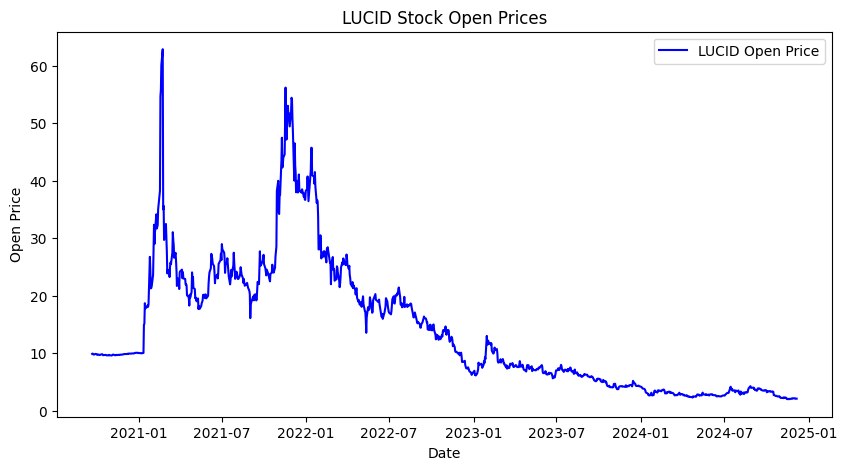

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import acorr_ljungbox as ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
!pip install hurst
from hurst import compute_Hc


ticker = "LCID"
data = yf.download(ticker, period="max", interval="1d")
data['log_returns'] = np.log(data['Open'].pct_change()+1)
data=data.dropna()
data['abs']=data['log_returns'].abs()
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['Open'], label="LUCID Open Price", color='blue')
plt.title("LUCID Stock Open Prices")
plt.xlabel("Date")
plt.ylabel("Open Price")
plt.legend()
plt.show()

We use Lucid stock price absolute log returns. the above is the price data. (Check challenge finding memory by student 1 to see more graphs on the data)

In [ ]:
lags = 10
ljung_box_results = ljungbox(data['abs'], lags=lags, return_df=True)

print("\nLjung-Box Test Results:")
print(ljung_box_results)
if any(ljung_box_results['lb_pvalue'] < 0.05):
    print("\nSignificant autocorrelation detected in absolute log returns (volatility clustering).")
else:
    print("\nNo significant autocorrelation detected in absolute log returns.")


Ljung-Box Test Results:
       lb_stat     lb_pvalue
1    25.190693  5.193221e-07
2    67.973450  1.736812e-15
3    70.224875  3.820366e-15
4    94.936491  1.175602e-19
5   104.930068  4.822259e-21
6   136.430437  5.675065e-27
7   148.338886  9.063416e-29
8   169.550052  1.602448e-32
9   176.074447  3.342092e-33
10  190.359595  1.645693e-35

Significant autocorrelation detected in absolute log returns (volatility clustering).


#**Diagam:**


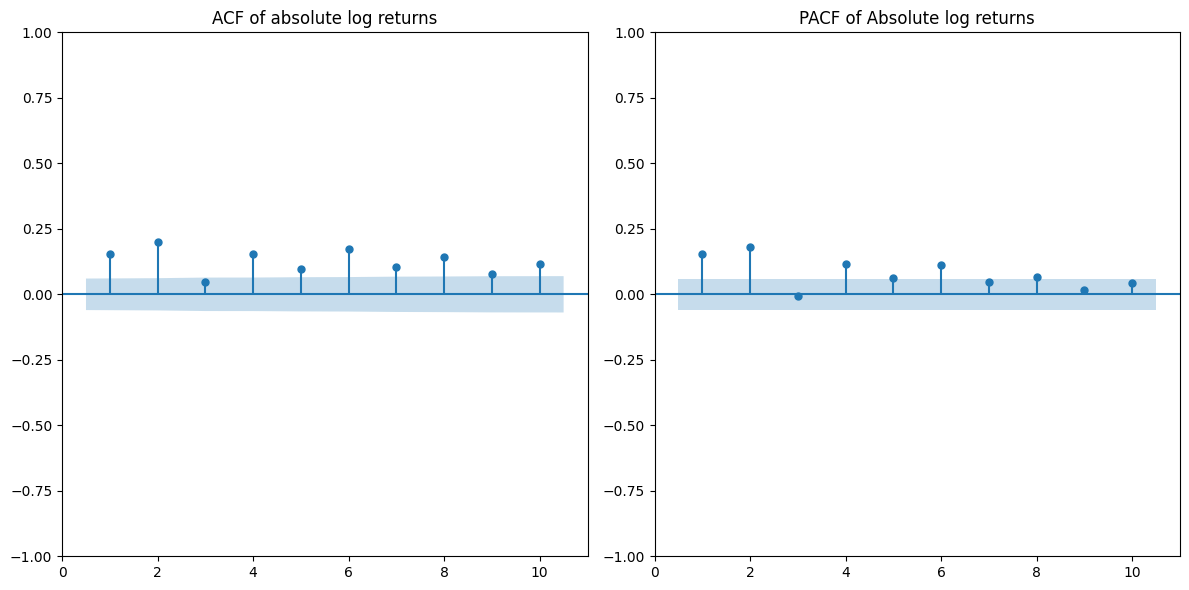

In [ ]:
plt.figure(figsize=(12, 6))

# ACF plot
plt.subplot(1, 2, 1)
plot_acf(data['abs'], lags=10, ax=plt.gca(), title="ACF of absolute log returns", zero=False)

# PACF plot
plt.subplot(1, 2, 2)
plot_pacf(data['abs'], lags=10, ax=plt.gca(), title="PACF of Absolute log returns", zero=False)

plt.tight_layout()
plt.show()

We see significant correlation and autocorrelation in the first 2 lags.


#**Diagnosis**:

We see from the acf and PACF plots that there is a significant autocorrelation and in the first 10 lags seems to have only a few values that are not significant. This confirms the demonstration above using Ljung-Box test which also indicated significant autocorrelation. We will see next how this relates to finding memory.


#**Damage:**

Not accounting for memory causes a huge problem in modeling time-series data as the out models (say i.i.d based model) can lead to sgnificant losses under our trading strategies that are built ubon that model. For example we will fall victims for crashes as the tend to have repititive high value absolute returns in the down side while we consider it to be a single +2-sigma event.



#**Directions:**

 If autocorrelation is found using Ljung-Box test or ACF/PACF adjust your model to account for it and choose the appropriate memory length for ARIMA/GARCH models. This can increase the predictive power of the model and increase the rewrard to risk ratio or accuracy for any other model.

#***Finding Memory:***



#**Description**:

***Memory*** is the dependence structure of a series over time with its own historical value. ACF is the the correlation of past values with present values. Statistical Tests like Ljung-Box are used for Identifying such structures with loosely defined alternative hypothesis and the null.
(Please see the group challenge above for more about Autocorrelation.

#**Technical Definition:**

###**Ljung-Box Q- test**:
Check the group challenge above for details

###**Hurst Exponent (Long-term memory check)**:

\begin{equation}
\log\left(\frac{R}{S}\right) = H \cdot \log(n) + C
\end{equation}

R/S is the rescaled range and n is the number of points

###**Breusch-Pagan test**:

This tests Heterosckedacity and volatility memory/clustering.


\begin{equation}
BP = \frac{n R^2}{2}
\end{equation}

null is homosckedacity

where:
- \(n\) is the number of observations,
- \(R^2\) is R-squared in regression


###**Graphical methods**

 **ACF: Autocorrelation function** (Check group challenge)



**PACF: Partial ACF** (Also check the challenge for the group above for definition)


#**Demonstration**:

We use Lucid stock information

In [ ]:

X = sm.add_constant(data['abs'])
model = sm.OLS(data['abs'], X).fit()
bp_test = het_breuschpagan(model.resid, X)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
bp_results = dict(zip(labels, bp_test))
print("Breusch-Pagan Test Results:")
for key, value in bp_results.items():
    print(f"{key}: {value}")
if bp_results['p-value'] < 0.05:
    print("\nSignificant heteroscedasticity detected (Absolute log return is not constant).")
else:
    print("\nNo significant heteroscedasticity detected (Absolute log return variance is constant).")

Breusch-Pagan Test Results:
Lagrange multiplier statistic: 729.9909012777115
p-value: 8.998669431414064e-161
f-value: 2335.4656033237397
f p-value: 4.0677214399234434e-270

Significant heteroscedasticity detected (Absolute log return is not constant).


In [ ]:
H, c, data_reg = compute_Hc(data['abs']+0.001, kind='price', simplified=True)
print(f"Hurst Exponent: {H}")

# Interpretation of the Hurst Exponent:
if H < 0.5:
    print("Hurst exponent suggests a mean reverting process (anti-persistent).")
elif H == 0.5:
    print("Hurst exponent suggests a random walk (Brownian motion).")
else:
    print("Hurst exponent suggests a persistent process (trending).")

Hurst Exponent: 0.2645428555870134
Hurst exponent suggests a mean reverting process (anti-persistent).


In [ ]:
data['abs'].min()

0.0

#**Diagram**:

In [ ]:


plt.figure(figsize=(10, 5))
plt.plot(data.index, data['log_returns'], label="LUCID Log Return", color='orange')
plt.title("LUCID Stock Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(data.index, data['abs'], label="LUCID Absolute Log Return", color='orange')
plt.title("LUCID Stock Log Returns")
plt.xlabel("Date")
plt.ylabel("Absolute Log Return")
plt.legend()
plt.show()

In the first diagram of Lucid stock price, there is an obvious downward trend but we see the log-returns as more stable around  mean of 0. Though there is some memory regarding volatility as it is clustered in the begining as we see in the absolute returns in graph 3. Confirming both Ljung-Box and BP tests.

#**Diagnosis**:

We can use the results above in the demonstration to have a quantitative idea about the existence on memory in the volatility in log return.

In addition. we can clearly see that there is significant Autocorrelation (check the autocorelation part) for Two lags in the absolute log returns of the price opening data.

#**Damage**:
Models like ARIMA or GARCH may fail to predict correctly if memory isn't accounted for as they work well when you account for the correct memory lag not just randomly.

For stock market applications, ignoring memory can lead to poor portfolio optimization or risk assessment as you build them under the assumption of wrong memory lags or no memory at all (i.i.d) with constant variance. Underwhich wrong strategies can be created.

#**Direction:**
first identify long-term dependencies in the data. using Hurst exponent or BP test. Once memory is found, you can determine the behavior (random, momentum, or mean reverting) or fit an appropriate model based on the length of the memory. Models like ARIMA and GARCH and their variants work well in many financial cases (EGARCH is an example of a variant model)

1- Ljung, G. M., & Box, G. E. P. (1978). On a measure of lack of fit in time series models. Biometrika, 65(2), 297–303. https://doi.org/10.1093/biomet/65.2.297

2- Hurst, H. E. (1951). Long-term storage capacity of reservoirs. Transactions of the American Society of Civil Engineers, 116(1), 770–799. https://doi.org/10.1061/TACEAT.0006518


